![Ronin of Data](https://www.dropbox.com/scl/fi/1y2uzce4b6dx96a8rc684/Ronin-of-Data-3.png?rlkey=q7h2fzzx0ql0h7189apdsok0r&st=n7og2p0o&raw=1)

<!-- Load the Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Cinzel:wght@700&display=swap" rel="stylesheet">

<h1 style="font-family: 'Cinzel', serif; font-size: 3em; color: #8B0000; text-align: center;">
  Welcome to Today's Mission: Cybersecurity Threats Analysis and Prediction
</h1>
<p style="font-family: 'Roboto', sans-serif; font-size: 1.5em; color: #333;">
  Hello Kagglers, data warriors, and chocolate aficionados! I’m your guide, 
  <strong style="color: #B22222;">Ronin of Data</strong>, leading you through battles on the data frontier. Get ready to conquer this dataset with flair and a sprinkle of humor!
</p>

*Prepare your analytical katana, embrace the art of strategy, and let’s slice through the data to reveal the secrets hidden within each chocolate sale. Your journey toward data mastery starts now!*

**Setup and Data Loading**

Before we dive into the fray, let's import our trusty libraries, suppress those pesky warnings, and load the dataset.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# Load the Data
df = pd.read_csv('/kaggle/input/global-cybersecurity-threats-2015-2024/Global_Cybersecurity_Threats_2015-2024.csv')
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


**Data Exploration**

The first step in our quest is to understand the terrain. We’ll explore the dataset by checking its structure, correlations, missing values, and any duplicated rows.

In [3]:
# Here’s a quick glimpse of our dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [4]:
# Correlations:
df.corr

<bound method DataFrame.corr of       Country  Year        Attack Type     Target Industry  \
0       China  2019           Phishing           Education   
1       China  2019         Ransomware              Retail   
2       India  2017  Man-in-the-Middle                  IT   
3          UK  2024         Ransomware  Telecommunications   
4     Germany  2018  Man-in-the-Middle                  IT   
...       ...   ...                ...                 ...   
2995       UK  2021         Ransomware          Government   
2996   Brazil  2023      SQL Injection  Telecommunications   
2997   Brazil  2017      SQL Injection                  IT   
2998       UK  2022      SQL Injection                  IT   
2999  Germany  2021      SQL Injection              Retail   

      Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                             80.53                    773169  Hacker Group   
1                             62.19                    295961  Ha

In [5]:
# Missing Values:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [6]:
# Duplicated Rows:
df.duplicated().sum()

0

**Visualizing Global Cybersecurity Threats**

Let’s dive into our visualizations to uncover insights into cybersecurity threats across the globe.

In [7]:
# Aggregate Financial Loss by Country
df_country_loss = df.groupby('Country')['Financial Loss (in Million $)'].sum().reset_index()

# Creat the choropleth map
fig = px.choropleth(
    df_country_loss,
    locations='Country',
    locationmode='country names',
    color='Financial Loss (in Million $)',
    color_continuous_scale='Inferno',
    title="Total Financial Loss by Country"
)

fig.show(renderer='iframe')

**Locational Insights: *Threats Categories Across Countries***

Next, let’s see how different types of attacks stack up by country using a pivot table and a heatmap.

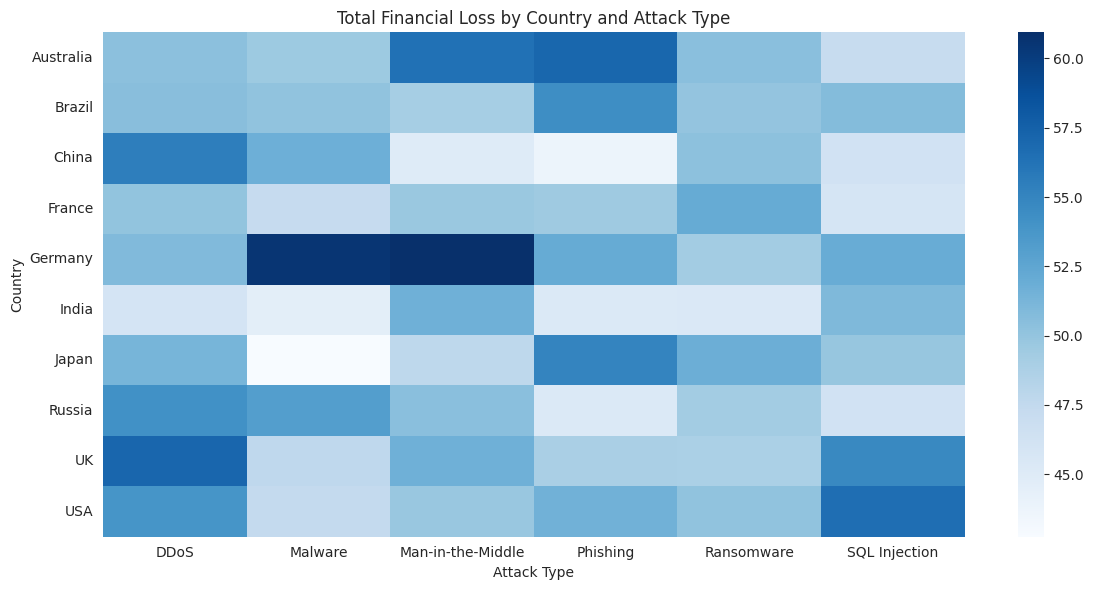

In [8]:
# Create a Pivot Table
pivot_table = df.pivot_table(index='Country', columns='Attack Type', values='Financial Loss (in Million $)')

# Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='Blues')
plt.xlabel("Attack Type")
plt.ylabel("Country")
plt.title("Total Financial Loss by Country and Attack Type")
plt.tight_layout()
plt.show()

**Trend Analysis Over Time**

Explore how financial losses have evolved over time with a line plot.

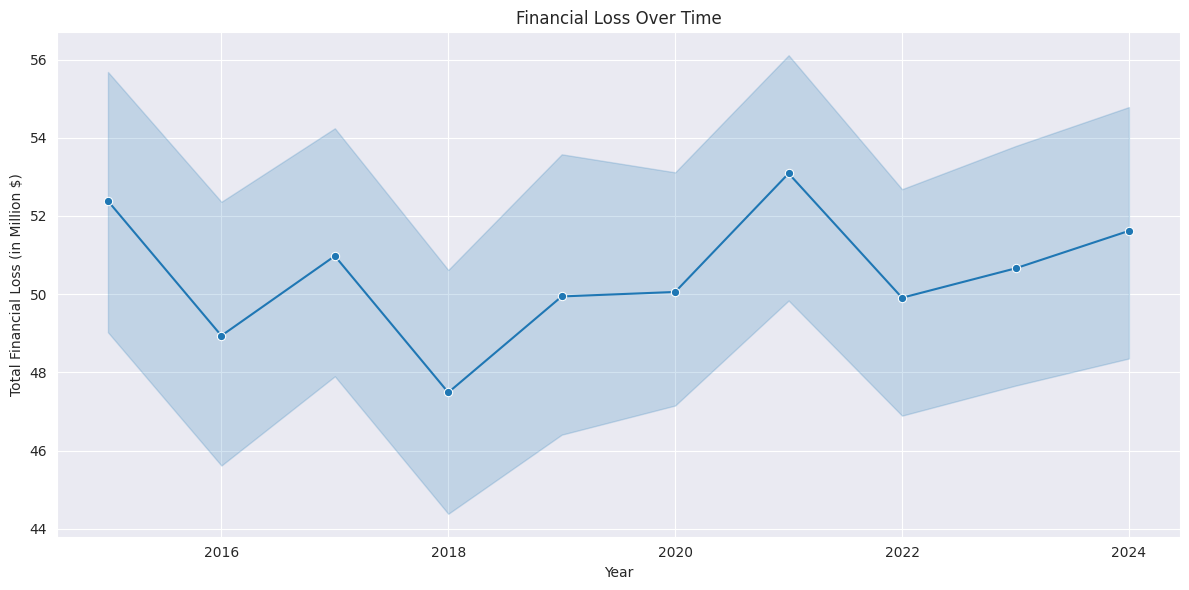

In [9]:
# Plot the sales trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Financial Loss (in Million $)', marker='o')
plt.xlabel("Year")
plt.ylabel("Total Financial Loss (in Million $)")
plt.title("Financial Loss Over Time")
plt.tight_layout()
plt.show()

**Exploring the Distribution of Numeric Columns**

Understanding the distribution of key numeric variables can reveal additional insights. Here, we explore the distributions of Year, Financial Loss, Number of Affected Users and Incident Resolution Time using histograms (with KDE).

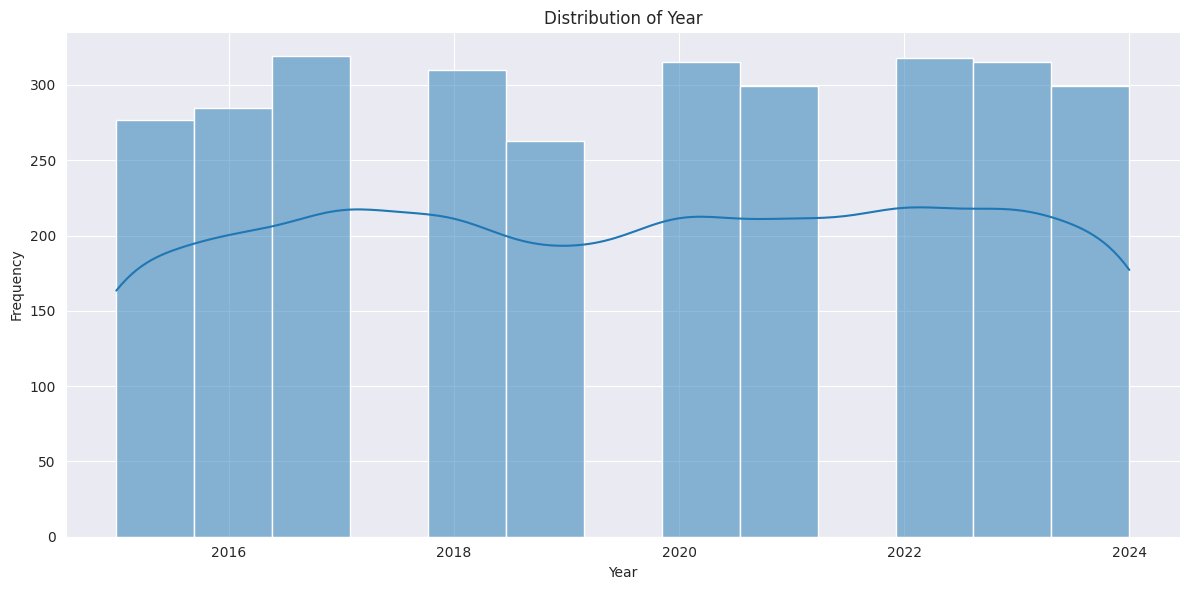

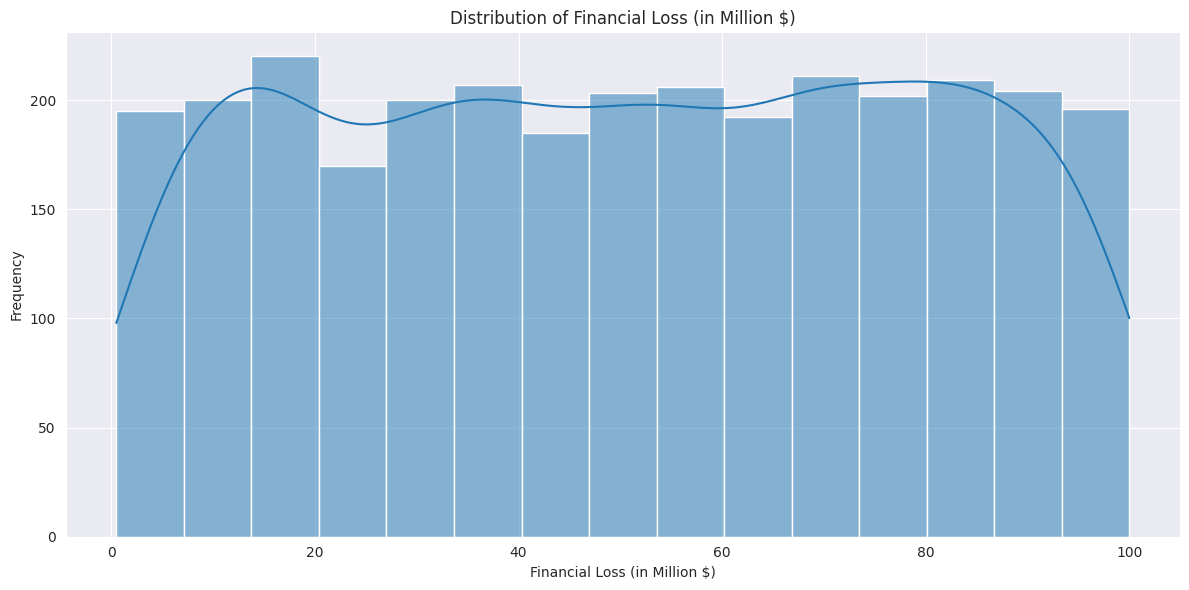

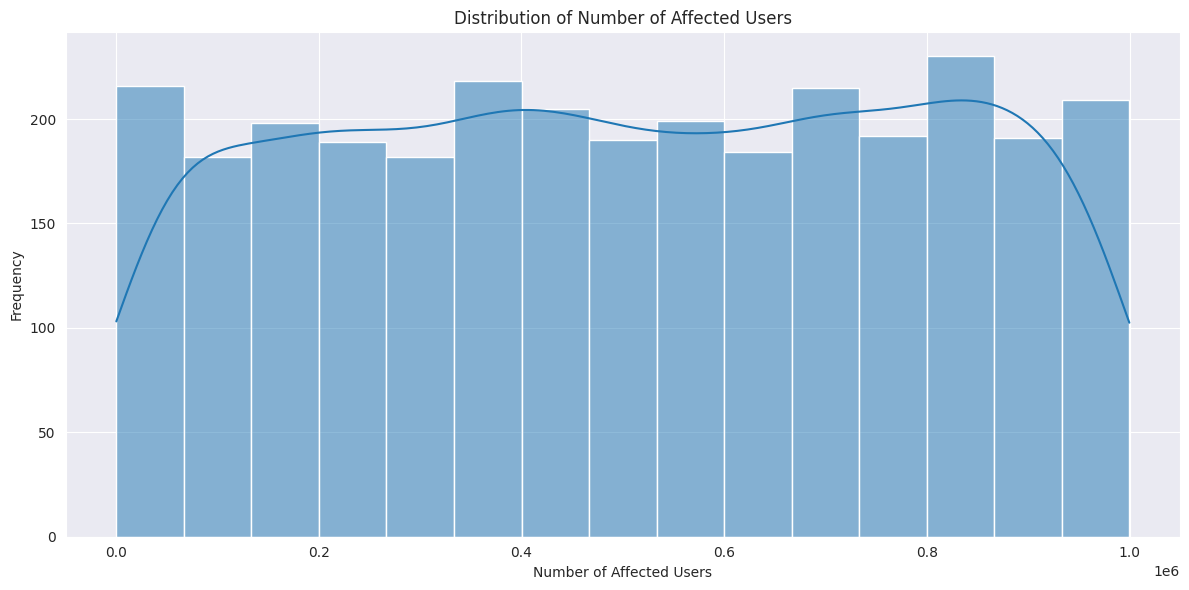

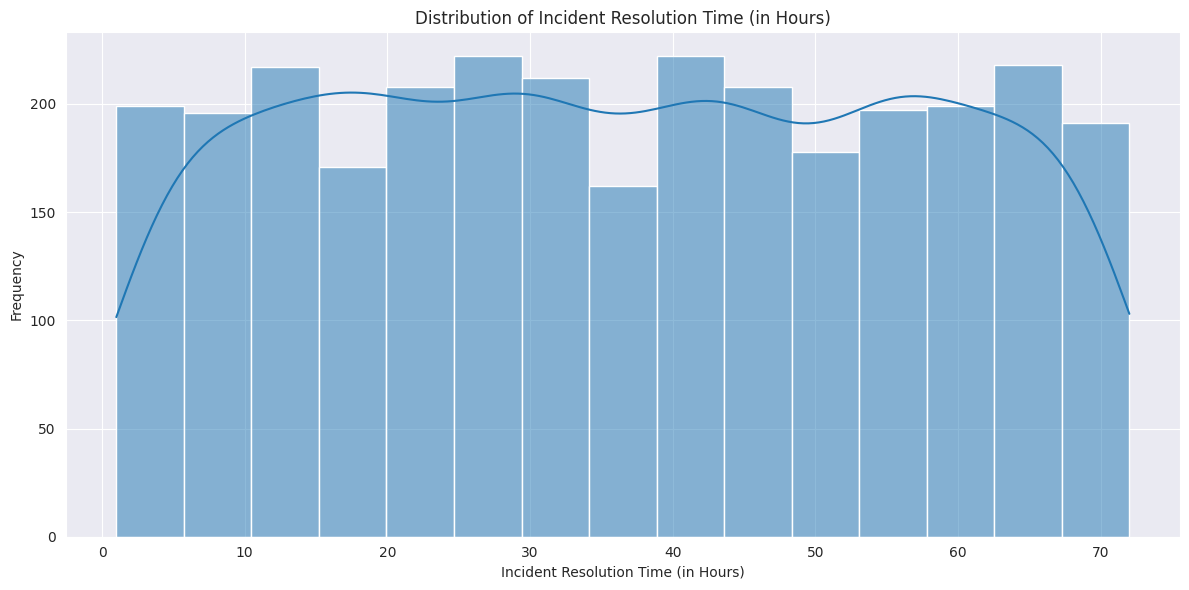

In [10]:
# Define Numeric Columns
numeric_cols = ['Year', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']

# Plot Distributions
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], kde=True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

**Exploring the Distribution of Categorical Columns**

Let’s now take a closer look at our categorical variables. We'll create count plots for each categorical column to understand the frequency distribution of each category.

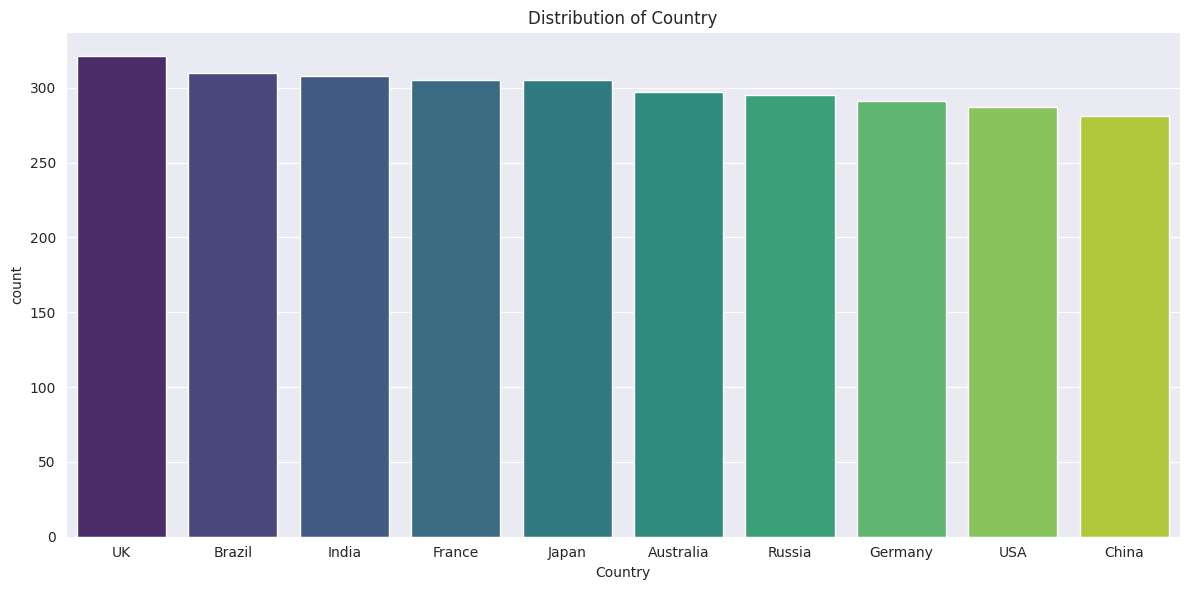

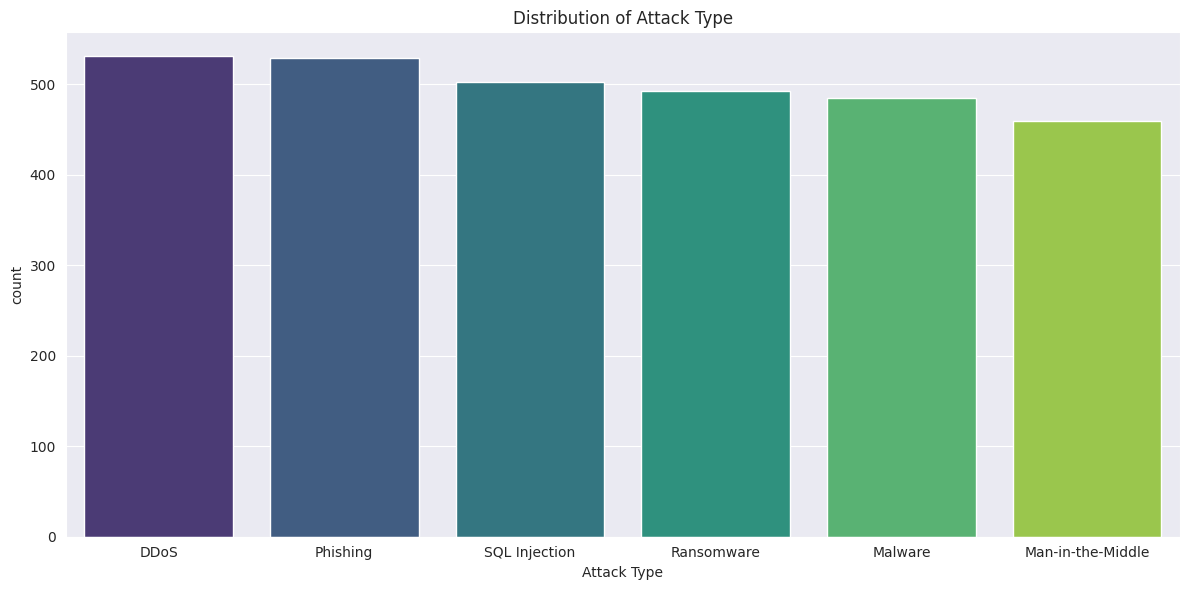

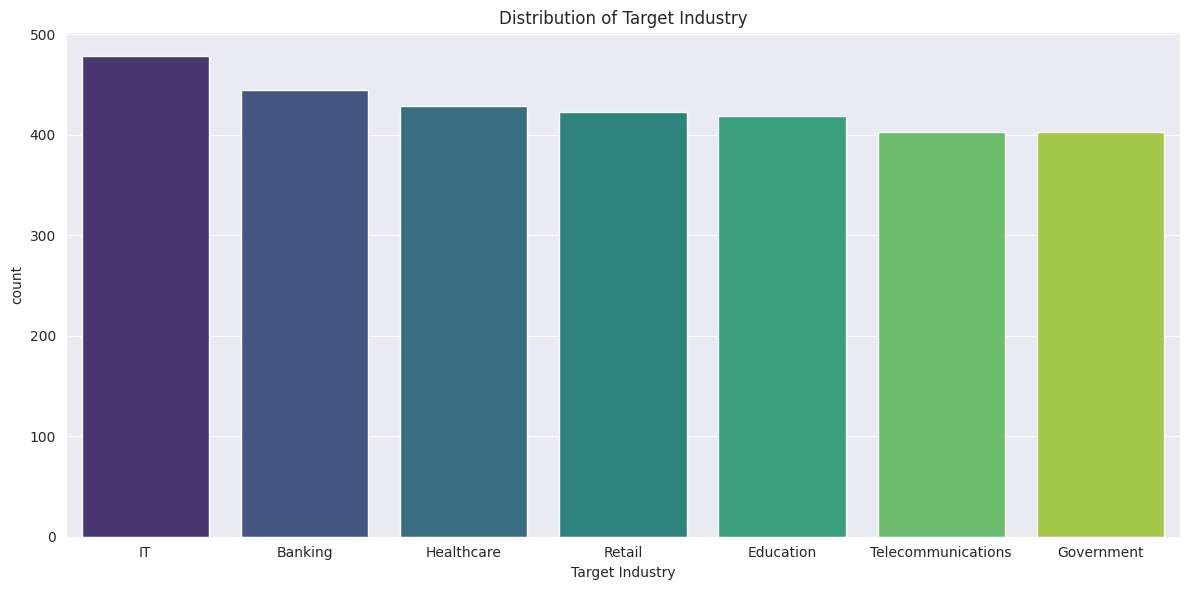

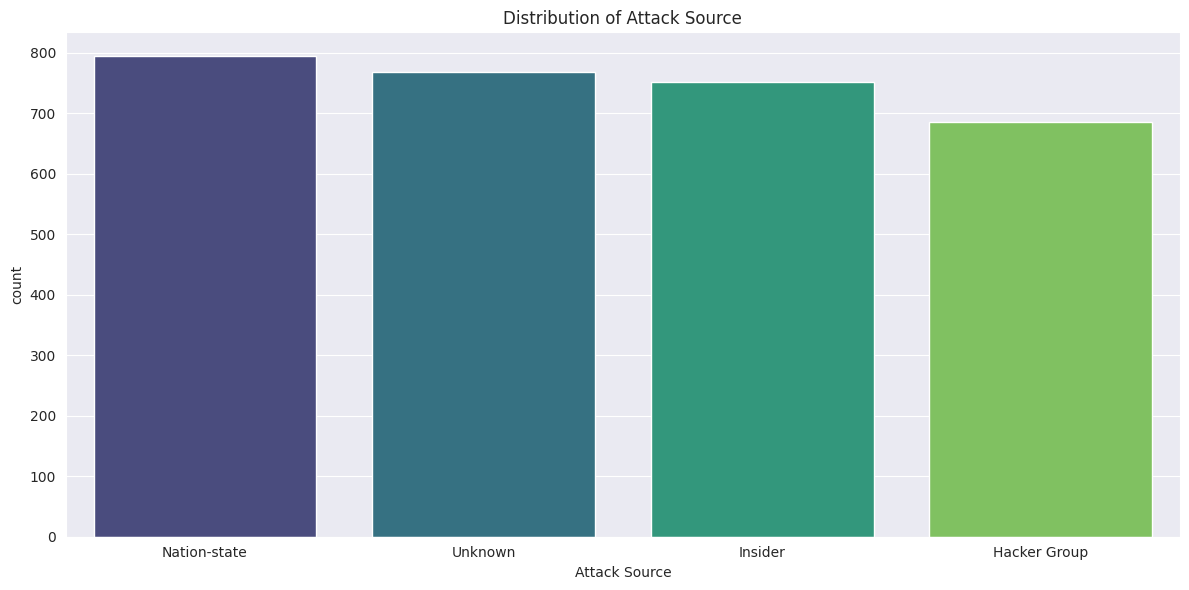

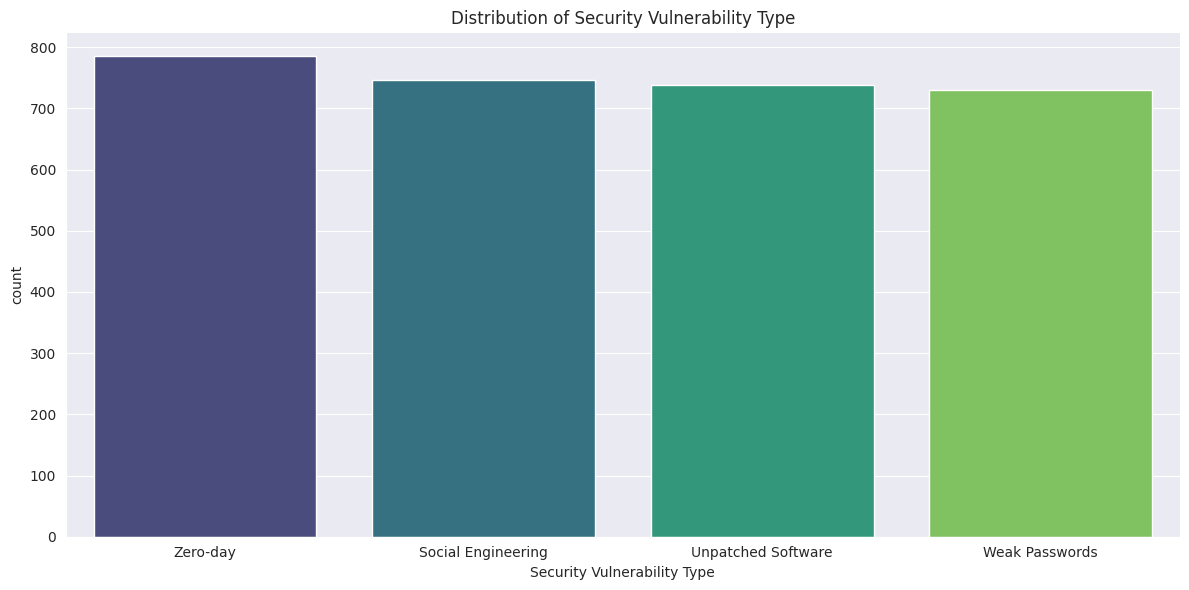

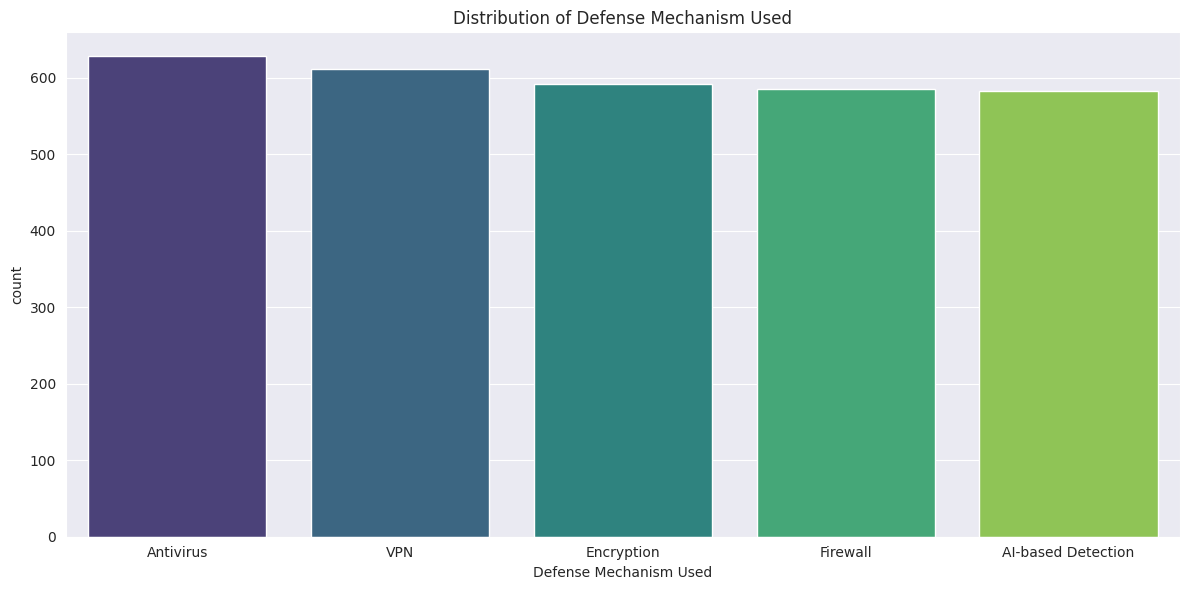

In [11]:
# Aggeragate the Categorical Columns
categorical_cols = ['Country', 'Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']

# Visualize with Count Plots
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    order = df[col].value_counts().index 
    sns.countplot(data=df, x=col, order=order, palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

**Now We Dive Into Our Predictive Modeling**

In our quest for a robust model with a higher R² score, we're elevating our approach by crafting a stacking ensemble. Like a master swordsman selecting the perfect techniques, this ensemble combines multiple base models to capture diverse patterns in our data and delivers that high-performance edge we need.

In [12]:
# Define our target variable and features
target = 'Financial Loss (in Million $)'
features = [
    'Year',
    'Attack Type',
    'Target Industry',
    'Attack Source',
    'Number of Affected Users',
    'Incident Resolution Time (in Hours)'
]

# Set up the feature matrix and target vector
X = df[features]
y = df[target]

# Identify the categorical features that need special handling
categorical_features = ['Attack Type', 'Target Industry', 'Attack Source']

# Identify the numerical features
numerical_features = ['Year', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']

# Create a ColumnTransformer to one-hot encode our categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ],
    remainder='passthrough'
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Building a Robust Stacking Ensemble**

 Here, we blend the power of a Random Forest, the precision of Ridge Regression, and the agility of XGBoost. A final estimator refines these predictions for improved performance.

In [13]:
# Define the base estimators
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('ridge', Ridge(alpha=1.0)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
]

# Create the stacking regressor with a robust final estimator
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0)
)

# Build the pipeline with the preprocessor and the stacking model
stacking_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', stacking_model)
])

# Train the ensemble model
stacking_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred_stack = stacking_pipeline.predict(X_test)

# Evaluate the model
r2_stack = r2_score(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
mae_stack = mean_absolute_error(y_test, y_pred_stack)

print('Stacking Regressor Performance:')
print(f'R² Score: {r2_stack:.3f}')
print(f'Mean Squared Error: {mse_stack:.3f}')
print(f'Mean Absolute Error: {mae_stack:.3f}')

Stacking Regressor Performance:
R² Score: -0.001
Mean Squared Error: 809.155
Mean Absolute Error: 24.611


<!-- Concluding Remarks --> <h2 style="font-family: 'Cinzel', serif; font-size: 2.5em; color: #8B0000; text-align: center;"> Mission Accomplished: The Cyber Chronicles Conclude! </h2> <p style="font-family: 'Roboto', sans-serif; font-size: 1.4em; color: #333;"> We've navigated the complex landscape of cybersecurity threats, unraveled the mysteries behind financial losses, and transformed raw data into insights as sharp as a samurai’s blade. Our journey has taken us from global maps to predictive modeling, all under the watchful eye of data's true warriors. </p> <p style="font-family: 'Roboto', sans-serif; font-size: 1.4em; color: #333;"> Thank you for joining <strong style="color: #B22222;">Ronin of Data</strong> on this epic quest. Keep your analytical katana honed and your curiosity aflame, for every data challenge is a new adventure. Until our next mission, remain bold, stay insightful, and be a true data warrior! </p>